# 无监督学习方法对比实验

本Notebook演示常见的无监督学习方法（聚类与降维），并通过可视化帮助理解各方法的效果和区别。

## 1. 导入必要的库

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score

## 2. 生成合成数据与加载Iris数据集

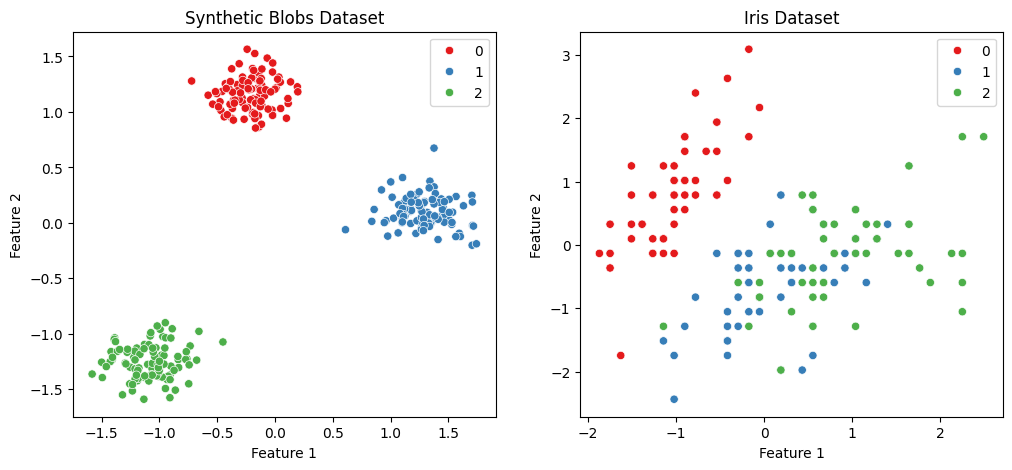

In [5]:
# 合成数据
# make_blobs生成300个样本，分为3个中心，随机状态为42，以确保结果可复现
X_blobs, y_blobs = datasets.make_blobs(n_samples=300, centers=3, random_state=42)
# 对数据进行标准化处理，使其具有零均值和单位方差，这有助于提高聚类算法的性能
X_blobs = StandardScaler().fit_transform(X_blobs)

# Iris数据集
iris = datasets.load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

# 把构造的数据和Iris数据可视化看看
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)    
sns.scatterplot(x=X_blobs[:, 0], y=X_blobs[:, 1], hue=y_blobs, palette='Set1')
plt.title('Synthetic Blobs Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_iris[:, 0], y=X_iris[:, 1], hue=y_iris, palette='Set1')
plt.title('Iris Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
# plt.savefig('Unsupervised_Learning/outputs/PCA/synthetic_iris.png')

## 3. 降维可视化（PCA & t-SNE）

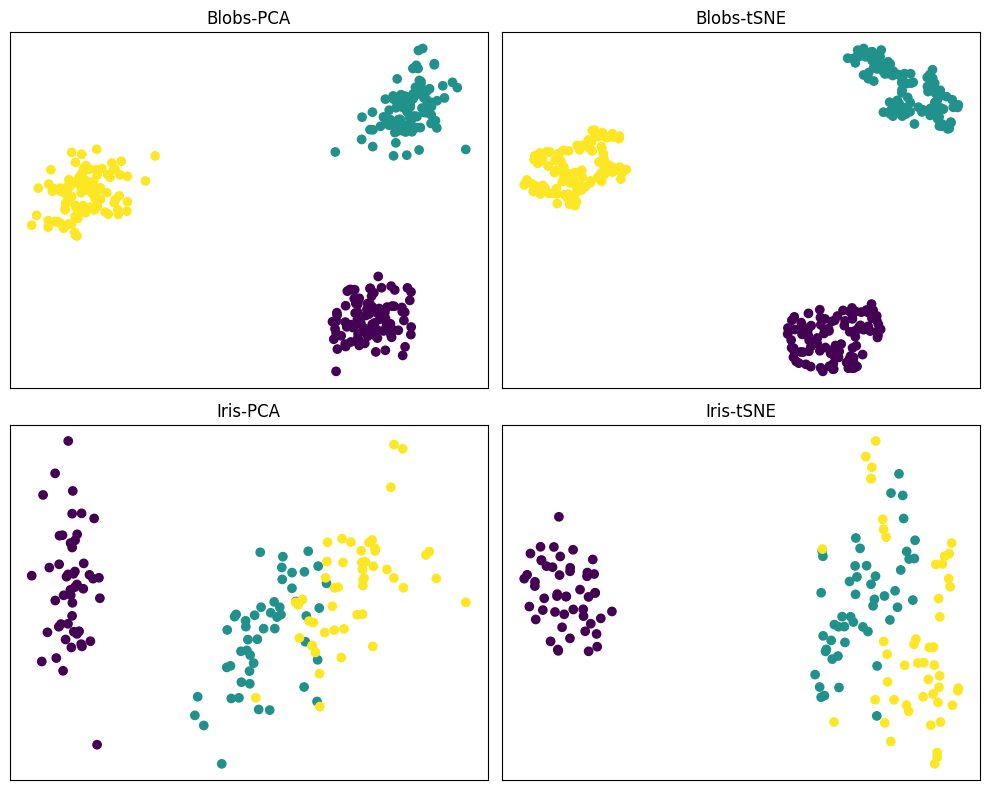

In [6]:
# 对合成数据和Iris数据分别做PCA和t-SNE降维
pca_blobs = PCA(n_components=2).fit_transform(X_blobs)
tsne_blobs = TSNE(n_components=2, random_state=42).fit_transform(X_blobs)
pca_iris = PCA(n_components=2).fit_transform(X_iris)
tsne_iris = TSNE(n_components=2, random_state=42).fit_transform(X_iris)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0,0].scatter(pca_blobs[:,0], pca_blobs[:,1], c=y_blobs, cmap='viridis')
axs[0,0].set_title('Blobs-PCA')
axs[0,1].scatter(tsne_blobs[:,0], tsne_blobs[:,1], c=y_blobs, cmap='viridis')
axs[0,1].set_title('Blobs-tSNE')
axs[1,0].scatter(pca_iris[:,0], pca_iris[:,1], c=y_iris, cmap='viridis')
axs[1,0].set_title('Iris-PCA')
axs[1,1].scatter(tsne_iris[:,0], tsne_iris[:,1], c=y_iris, cmap='viridis')
axs[1,1].set_title('Iris-tSNE')
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 4. 聚类算法对比（KMeans、DBSCAN、层次聚类）

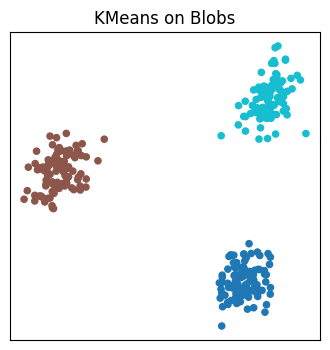

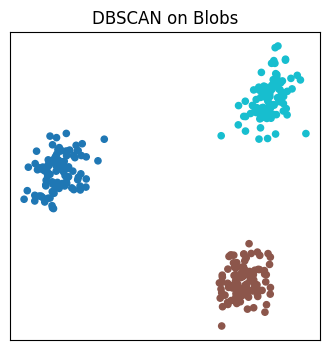

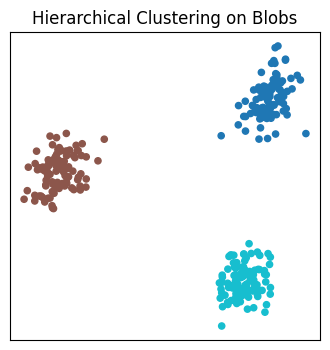

In [10]:
def plot_clusters(X_2d, labels, title):
    plt.figure(figsize=(4,4))
    plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, cmap='tab10', s=20)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# 对合成数据做聚类
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_blobs)
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(X_blobs) # DBSCAN不需要指定簇的数量，但需要设置eps和min_samples参数
hc = AgglomerativeClustering(n_clusters=3).fit(X_blobs)

# 用PCA降维后可视化
X_blobs_pca = PCA(n_components=2).fit_transform(X_blobs)
plot_clusters(X_blobs_pca, kmeans.labels_, 'KMeans on Blobs')
plot_clusters(X_blobs_pca, dbscan.labels_, 'DBSCAN on Blobs')
plot_clusters(X_blobs_pca, hc.labels_, 'Hierarchical Clustering on Blobs')

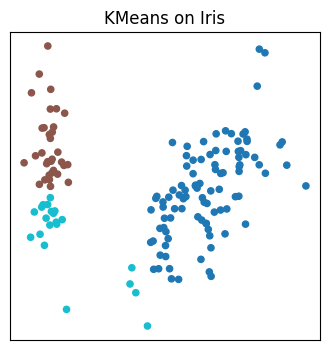

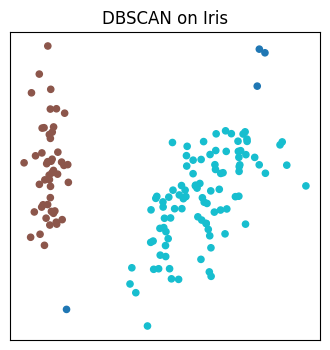

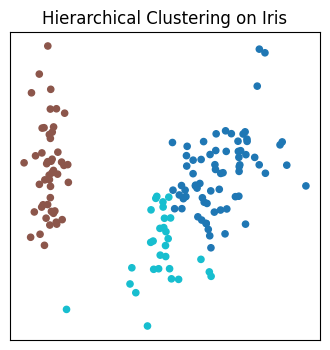

In [11]:
# 对Iris数据做聚类
kmeans_iris = KMeans(n_clusters=3, random_state=42).fit(X_iris)
dbscan_iris = DBSCAN(eps=0.8, min_samples=5).fit(X_iris)
hc_iris = AgglomerativeClustering(n_clusters=3).fit(X_iris)

X_iris_pca = PCA(n_components=2).fit_transform(X_iris)
plot_clusters(X_iris_pca, kmeans_iris.labels_, 'KMeans on Iris')
plot_clusters(X_iris_pca, dbscan_iris.labels_, 'DBSCAN on Iris')
plot_clusters(X_iris_pca, hc_iris.labels_, 'Hierarchical Clustering on Iris')

## 5. 聚类效果评价（ARI）

In [ ]:
# 计算ARI分数
print('Blobs数据集:')
# ARI (Adjusted Rand Index)是一个衡量聚类结果与真实标签之间相似度的指标，值越接近1表示聚类结果越好，值为0表示随机聚类，负值表示聚类结果比随机还差。
print('KMeans ARI:', adjusted_rand_score(y_blobs, kmeans.labels_))
print('DBSCAN ARI:', adjusted_rand_score(y_blobs, dbscan.labels_))
print('层次聚类 ARI:', adjusted_rand_score(y_blobs, hc.labels_))

print('\nIris数据集:')
print('KMeans ARI:', adjusted_rand_score(y_iris, kmeans_iris.labels_))
print('DBSCAN ARI:', adjusted_rand_score(y_iris, dbscan_iris.labels_))
print('层次聚类 ARI:', adjusted_rand_score(y_iris, hc_iris.labels_))

Blobs数据集:
KMeans ARI: 1.0
DBSCAN ARI: 1.0
层次聚类 ARI: 1.0

Iris数据集:
KMeans ARI: 0.432804702527474
DBSCAN ARI: 0.5517553852833211
层次聚类 ARI: 0.6153229932145449
